# The digital grid: `BitMatrix`

A [`BitMatrix`](../../doc/data_structures.md#bit-matrix) is a digital set over a
rectangular window of $\mathbb{Z}^{2}$, one bit per cell, packed into 64-bit
words. Cell $(x, y)$ denotes the unit square $[x, x+1] \times [y, y+1]$, named by
its lower-left corner, so the covered region is a union of closed unit squares.

It is the representation to reach for when the geometry is rectilinear: the set
algebra, the Minkowski operations, connectivity and morphology all run a machine
word at a time, against the polynomial cost of the same questions on exact
polygonal boundaries. The restriction is that only grid-representable sets are
expressible.

`BitMatrix` has no counterpart script in [`examples/`](..), so this notebook is
its only worked treatment. See [`tour.ipynb`](tour.ipynb) for the library's
conventions and [`booleans.ipynb`](booleans.ipynb) for the exact-polygon
analogues of the operations below.

In [1]:
import pypgl as pgl

pgl.REPR_SVG_SIZE = 260


def figure(*layers, size=300):
    """Draw (shape, stroke, fill) layers onto one canvas, in order."""
    canvas = pgl.Canvas().size(size, size).margin(12).strokeWidth(1.5)
    for shape, stroke, fill in layers:
        canvas.stroke(stroke).fill(fill).draw(shape)
    return canvas

## Construction

The window is fixed at construction and never grows: a write outside it is a
no-op and a read outside it is `False`, so the extent is chosen by the caller.
A cell is named by a pair of `int`s or by a `Point`, interchangeably.

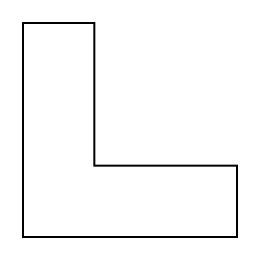

In [2]:
m = pgl.BitMatrix(0, 0, 6, 4)          # 6 x 4 cells, lower-left at (0, 0)
m.set(0, 0)
m.set(pgl.Point(1, 0))                 # equivalent spelling
m.set([(2, 0), (0, 1), (0, 2)])        # a range of cells

m

Drawing a matrix streams the region its cells cover, so adjacent cells merge into
a single path. Drawing them individually shows the lattice, and exercises the
container protocol.

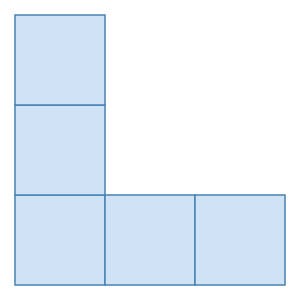

In [3]:
cells = [pgl.Rectangle(c, c + pgl.Point(1, 1)) for c in m]

figure((cells, "steelblue", "#cfe3f5"))

`len(matrix)` counts set cells, iteration yields them as `Point`s in row-major
order, and `point in matrix` tests whether *that cell* is set — the question
`get` answers, not membership in the covered region.

In [4]:
print("set cells:", len(m), " window:", m.window())
print("(1,0) is set:", pgl.Point(1, 0) in m)
print("(5,3) is set:", pgl.Point(5, 3) in m)

set cells: 5  window: [(0,0),(6,4)]
(1,0) is set: True
(5,3) is set: False


### Digitization of a shape

`BitMatrix(polygon)`, spelled `polygon.asBitMatrix()`, digitizes a `Polygon`,
`PolygonWithHoles` or `PolygonSet` all of whose edges are axis-parallel, over its
bounding box. Every edge then lies on a grid line, so the digitization is exact
rather than an approximation: area is preserved and the inverse map recovers the
region.

cells: 51  matrix area: 51  polygon area: 51
round trip is the same region: True


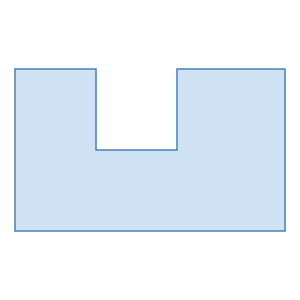

In [5]:
plan = pgl.Polygon([0,0, 10,0, 10,6, 6,6, 6,3, 3,3, 3,6, 0,6])
grid = plan.asBitMatrix()

print("cells:", grid.count(), " matrix area:", grid.area(), " polygon area:", plan.area())
print("round trip is the same region:", grid.asPolygonSet().samePointSet(plan))

figure((grid, "steelblue", "#cfe3f5"))

## Set algebra

`&`, `|`, `^` and `difference` are the set operations; `andCount`, `orCount` and
`xorCount` return the cardinalities without materializing the result. Each
result takes the smallest window that provably loses no cell, while the compound
`&=`, `|=`, `^=` retain their window and drop what falls outside, as `set` does.

`~` complements **within the window**, not against the plane.

intersection: 8  (without building it: 8 )
union:        53
difference:   28


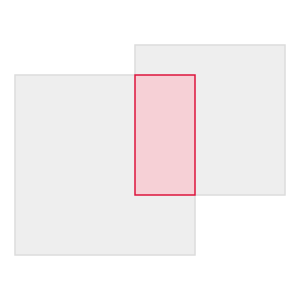

In [6]:
left  = pgl.BitMatrix([(x, y) for x in range(0, 6) for y in range(0, 6)])
right = pgl.BitMatrix([(x, y) for x in range(4, 9) for y in range(2, 7)])

print("intersection:", (left & right).count(), " (without building it:", left.andCount(right), ")")
print("union:       ", (left | right).count())
print("difference:  ", left.difference(right).count())

figure((left | right,  "gainsboro",  "#eeeeee"),
       (left & right,  "crimson", "#f6d0d6"))

## Two readings of a cell

The method set comes in pairs because a cell admits two interpretations:

- as a **region**, the unit square it covers. This is what the predicates,
  `area`, `perimeter`, `centroid`, `bbox`, `convexHull`, the symmetries and
  `minkowskiSum` answer for, and all of them commute with `asPolygonSet()`.
- as a **lattice point**, the element of $\mathbb{Z}^{2}$ at its lower-left
  corner. This is what every `lattice`-prefixed operation works in, and it is the
  reading under which a structuring element behaves as one.

The two differ by the diagonal shift $(1,1)$: reflecting the square sends its
lower-left corner to the opposite side, so `reflected()` maps $c \mapsto -c -
(1,1)$ where `latticeReflected()` maps $c \mapsto -c$.

In [7]:
corner = pgl.BitMatrix([(0, 0), (1, 0), (0, 1)])

def cells_of(matrix):
    return sorted((int(c.x()), int(c.y())) for c in matrix)

print("original:         ", cells_of(corner))
print("reflected():      ", cells_of(corner.reflected()))
print("latticeReflected():", cells_of(corner.latticeReflected()))

original:          [(0, 0), (0, 1), (1, 0)]
reflected():       [(-2, -1), (-1, -2), (-1, -1)]
latticeReflected(): [(-1, 0), (0, -1), (0, 0)]


Transposition is the involution the two readings agree on, so `transposed()` and
`latticeTransposed()` coincide. Translation likewise, spelled `matrix + point`.

### Which reading a Minkowski sum takes

`latticeMinkowskiSum` is the Minkowski sum in $\mathbb{Z}^{2}$, so a one-cell
matrix is its identity — the property a structuring element must have.
`minkowskiSum` sums the covered **regions**, for which the unit square $U$ is not
an identity: $U \oplus U$ is the $2 \times 2$ square, so the region sum is one
cell wider and one taller in each direction.

In [8]:
unit = pgl.BitMatrix(0, 0, 1, 1)
unit.setAll()

print("original:          ", repr(grid))
print("lattice sum by U:  ", repr(grid.latticeMinkowskiSum(unit)))
print("region  sum by U:  ", repr(grid.minkowskiSum(unit)))

original:           BitMatrix[10x6 from (0,0), 51 cells]
lattice sum by U:   BitMatrix[10x6 from (0,0), 51 cells]
region  sum by U:   BitMatrix[11x7 from (0,0), 71 cells]


## Morphology

`latticeMinkowskiErosion` is the erosion $\varepsilon_B$ dual to the lattice
dilation $\delta_B$: the points $p$ with $p \oplus B \subseteq A$. Their
compositions are the opening $\gamma_B = \delta_B \varepsilon_B$
(anti-extensive, idempotent — it deletes what admits no placement of $B$) and the
closing $\varphi_B = \varepsilon_B \delta_B$ (extensive, idempotent — it fills
what admits none in the complement).

Applied to a noisy digitization: a rectangular blob with two punched cells and
five isolated cells around it.

cells: 83  components: 6  holes: 2


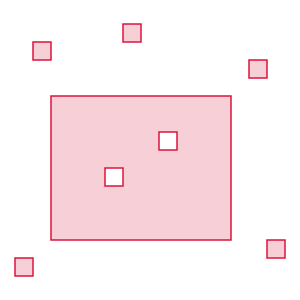

In [9]:
blob  = [(x, y) for x in range(2, 12) for y in range(2, 10)
                if (x, y) not in {(5, 5), (8, 7)}]
noise = [(0, 0), (14, 1), (13, 11), (1, 12), (6, 13)]

noisy = pgl.BitMatrix(blob + noise)
print("cells:", noisy.count(), " components:", noisy.componentCount(), " holes:", noisy.holeCount())

figure((noisy, "crimson", "#f6d0d6"))

opened: 78 cells in 1 component(s)
closed: 80 cells with 0 hole(s)


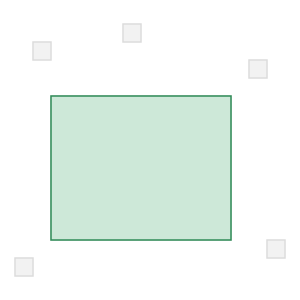

In [10]:
element = pgl.BitMatrix(0, 0, 2, 2)
element.setAll()

opened = noisy.latticeOpening(element)      # gamma_B: drops the isolated cells
closed = opened.latticeClosing(element)     # phi_B: fills the punched cells

print("opened:", opened.count(), "cells in", opened.componentCount(), "component(s)")
print("closed:", closed.count(), "cells with", closed.holeCount(), "hole(s)")

figure((noisy,  "gainsboro", "#f2f2f2"),
       (closed, "seagreen", "#cde8d8"))

### Admissible placements

The erosion answers the same question on the grid that it answers for exact
polygons in [`booleans.ipynb`](booleans.ipynb): every cell of the result is a
translation at which the structuring element lies inside the set.

room: 72 cells   free positions: 53   connected: True


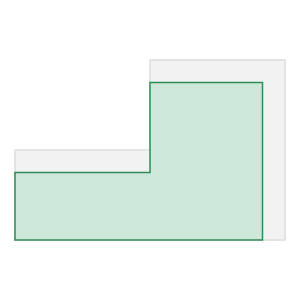

In [11]:
room  = pgl.Polygon([0,0, 12,0, 12,8, 6,8, 6,4, 0,4]).asBitMatrix()
robot = pgl.BitMatrix(0, 0, 2, 2)
robot.setAll()

free = room.latticeMinkowskiErosion(robot)
print("room:", room.count(), "cells   free positions:", free.count(),
      "  connected:", free.isConnected())

figure((room, "gainsboro", "#f2f2f2"),
       (free, "seagreen", "#cde8d8"))

## Connectivity

`connectedComponents` returns one trimmed matrix per component, with `adjacency`
either `GridAdjacency.edge` (4-connectivity, the default) or
`GridAdjacency.vertex` (8-connectivity). The background is always traversed under
the complementary adjacency — the standard pairing that avoids the connectivity
paradox, under which a diagonal chain would be connected while the background
leaked through it.

In [12]:
diagonal = pgl.BitMatrix([(i, i) for i in range(4)])

print("edge  adjacency:", diagonal.componentCount(pgl.GridAdjacency.edge), "components")
print("vertex adjacency:", diagonal.componentCount(pgl.GridAdjacency.vertex), "component")

edge  adjacency: 4 components
vertex adjacency: 1 component


In [13]:
ring = pgl.BitMatrix([(x, y) for x in range(5) for y in range(5)
                             if not (1 <= x <= 3 and 1 <= y <= 3)])

print("cells:", ring.count(), " holes:", ring.holeCount(),
      " Euler number:", ring.eulerNumber())
print("after fillHoles:", ring.fillHoles().count(), "cells")

cells: 16  holes: 1  Euler number: 0
after fillHoles: 25 cells


`interior(adjacency)` returns the set cells all of whose neighbours are set and
`boundary(adjacency)` the remainder, a cell on the window border always counting
as boundary. `eulerNumber` is components minus holes, the digital Euler
characteristic.

In [14]:
block = pgl.BitMatrix([(x, y) for x in range(6) for y in range(6)])

print("4-neighbour interior:", block.interior().count(),
      " boundary:", block.boundary().count())
print("8-neighbour interior:", block.interior(pgl.GridAdjacency.vertex).count())

4-neighbour interior: 16  boundary: 20
8-neighbour interior: 16


## hv-convexity

A digital set is row convex when no row has a gap, column convex likewise, and
hv-convex when both hold — the regularity condition under which reconstruction
from horizontal and vertical projections becomes tractable in discrete
tomography. `makeHvConvex()` alternates the two fills to a fixed point in place
and returns the number of cells added, giving the smallest hv-convex superset.

In [15]:
corners = pgl.BitMatrix([(0, 0), (4, 0), (0, 4), (4, 4)])
print("hv-convex to begin with:", corners.isHvConvex())

added = corners.makeHvConvex()
print("cells added:", added, "  now:", corners.count(), " hv-convex:", corners.isHvConvex())

hv-convex to begin with: False
cells added: 21   now: 25  hv-convex: True


## Back to exact geometry

`asPolygonWithHoles()` and `asPolygonSet()` return the covered region as exact
shapes, and every region-reading operation commutes with that conversion:
measuring the matrix and measuring its polygon set agree, being the same
region.

In [16]:
region = closed.asPolygonSet()

print(type(region).__name__, "with", region.componentCount(), "component")
print("matrix area:", closed.area(), "  region area:", region.area())
print("centroids agree:", closed.centroid() == region.centroid())

PolygonSet with 1 component
matrix area: 80   region area: 80
centroids agree: True


## Further

- [`doc/data_structures.md`](../../doc/data_structures.md#bit-matrix) — the full
  method list, including the window arithmetic each operation performs.
- [`booleans.ipynb`](booleans.ipynb) — the same set algebra and morphology on
  exact polygons, without the rectilinearity restriction.
- [`motion.ipynb`](motion.ipynb) — the erosion applied to motion planning.
- [`doc/shapes.md`](../../doc/shapes.md) — `latticePoints()`, the other map from
  a shape to $\mathbb{Z}^{2}$: the lattice points a shape contains, with no
  digitization involved.